## Introduction

In [45]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


import sys
sys.path.append("../../")
import methods
from methods import assure

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
def load_data_for_outcome(est_var):
    """
    Load the processed data for a given outcome variable
    Filter out missing values and values where the standard error is too large
    """
    df = pd.read_feather("data/oa_data_used.feather")
    se_var = est_var + "_se"
    subset = df[[est_var, se_var, "czname", "state", "county", "tract"]].dropna()
    thresh = subset[se_var].quantile(0.995)
    subset = subset.loc[subset[se_var] <= thresh].reset_index(drop=True)

    return subset

est_var = "kfr_black_pooled_p25"
df = load_data_for_outcome(est_var)
estimates = df[est_var].values
standard_errors = df[est_var + "_se"].values

In [47]:
print(df.shape)
df.head(10)

#df.to_csv('OA_kfr_black_pooled_p25.csv')

(13600, 6)


,kfr_black_pooled_p25,kfr_black_pooled_p25_se,czname,state,county,tract
0,0.436884,0.085585,Phoenix,4,13,40530
1,0.346071,0.058589,Phoenix,4,13,60901
2,0.315429,0.060964,Phoenix,4,13,60903
3,0.473322,0.072297,Phoenix,4,13,60904
4,0.395562,0.079358,Phoenix,4,13,61009
5,0.392928,0.068944,Phoenix,4,13,61011
6,0.339815,0.066531,Phoenix,4,13,61012
7,0.670783,0.069815,Phoenix,4,13,61014
8,0.291308,0.049117,Phoenix,4,13,61015
9,0.295808,0.061246,Phoenix,4,13,61022


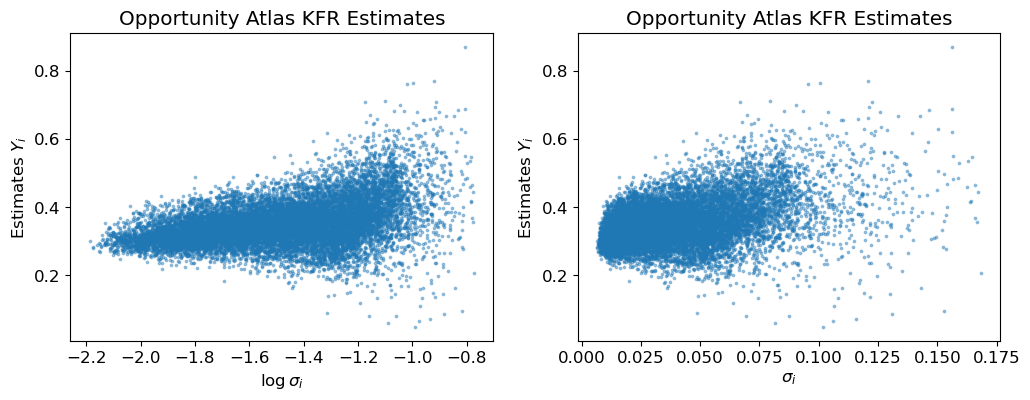

In [48]:
fig, ax = plt.subplots(1,2, figsize = (12,4))
ax[0].scatter(np.log10(standard_errors), estimates, s = 3, alpha = 0.4, rasterized=True)
ax[0].set_title("Opportunity Atlas KFR Estimates")
ax[0].set_xlabel("$\log \sigma_i$")
ax[0].set_ylabel("Estimates $Y_i$")
#ax[0].axhline(y = 0.25, linewidth = 1, alpha = 0.8, linestyle = "dashed", color = "black")

ax[1].scatter(standard_errors, estimates, s = 3, alpha = 0.4, rasterized=True)
ax[1].set_title("Opportunity Atlas KFR Estimates")
ax[1].set_xlabel("$\sigma_i$")
ax[1].set_ylabel("Estimates $Y_i$")

plt.savefig("oa_viz.pdf",bbox_inches = 'tight',dpi=300)


In [49]:
Ys = estimates
grand_mean = np.mean(estimates)

grand_mean_weighted = np.sum(Ys / standard_errors**2) / np.sum(1 / standard_errors**2)

sigmas = standard_errors
ts = Ys / sigmas
grand_var = np.var(Ys) - np.mean(sigmas**2)

grand_var_weighted = np.sum(
    ((Ys - grand_mean_weighted) ** 2 - sigmas**2) * (1 / sigmas**2)
) / np.sum(1 / sigmas**2)


In [50]:
shrink = sigmas**2/(sigmas**2 + grand_var)
eb_posterior_means = grand_mean*shrink + Ys*(1-shrink)
eb_implied_cost = pd.Series(eb_posterior_means).quantile(0.67)
print(eb_implied_cost)


0.36122944621657416


In [51]:
def linear_shrinkage_threshold_fn(ratio, cost):
    # Consider linear shrinkage to the grand mean where prior_scale controls the amount of
    # shrinkage
    thresh = cost + ratio[None, :] * (sigmas**2)[:, None]
    return thresh


def t_ratio_threshold_fn(t_thresh):
    return t_thresh * standard_errors

In [52]:
def plot_performance(params, cost, ax, se=True):
    eb_param = (cost - grand_mean) / (grand_var)
    # eb_param_weighted = (cost - grand_mean_weighted) / (grand_var_weighted)

    welfare, welfare_se = assure(
        Ys,
        sigmas,
        lambda params: linear_shrinkage_threshold_fn(params, cost=cost),
        params,
        costs=cost,
    )

    thresholds = linear_shrinkage_threshold_fn(params, cost)
    selected = (Ys[:, None] > thresholds).mean(axis=0)

    ax.plot(params, welfare, ls="-", label="ASSURE")
    # ax.plot(params, selected, ls=":", label="Selected Proportion", color="gray")
    if se:
        ax.plot(params, welfare + 1.96 * welfare_se, ls="--", color="gray")
        ax.plot(params, welfare - 1.96 * welfare_se, ls="--", color="gray")
    ax.axvline(eb_param, ls="--", color="red", label="Implied tuning by plug-in EB")
    # ax.axvline(eb_param_weighted, ls="--", color="purple", label="Implied tuning by plug-in EB (weighted)", alpha=0.5)
    ax.set_xlabel("$(K-m_0)/s_0^2$")
    sns.despine()

0.3698203636


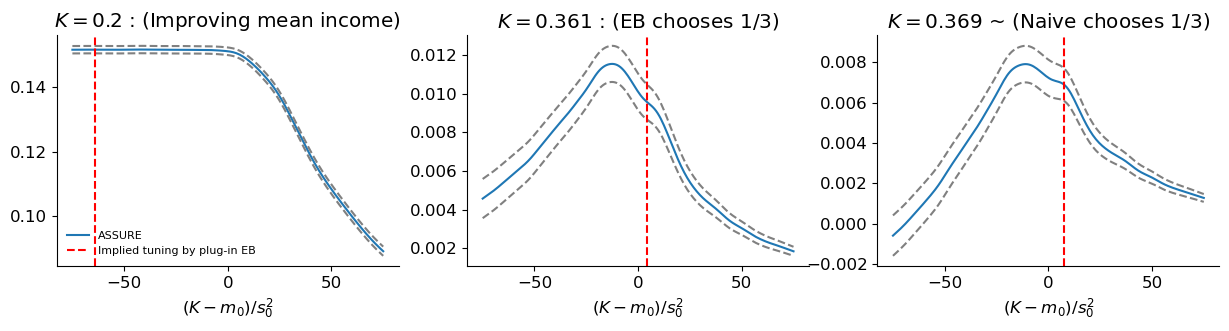

In [53]:
plt.rcParams.update({'font.size': 12})

f, aYs = plt.subplots(1, 3, figsize=(15, 3))
params = np.linspace(-75, 75, 200)
plot_performance(params, 0.2, aYs[0])
aYs[0].set_title("$K = 0.2$ : (Improving mean income)")

plot_performance(params, eb_implied_cost, aYs[1])
aYs[1].set_title("$K = 0.361$ : (EB chooses 1/3)")

naive_implied_cost = pd.Series(Ys).quantile(0.67)
print(naive_implied_cost)
plot_performance(params, naive_implied_cost, aYs[2])
aYs[2].set_title("$K = 0.369$ ~ (Naive chooses 1/3)")

aYs[0].legend(loc="lower left", fontsize=8, frameon=False)
plt.savefig("opportunity_atlas_analysis.pdf", bbox_inches="tight")

In [55]:
cost = 0.361
params = np.linspace(-75, 75, 200)
welfare, welfare_se = assure(
    Ys,
    sigmas,
    lambda params: linear_shrinkage_threshold_fn(params, cost=cost),
    params,
    costs=cost,
)

In [72]:
opt_beta = params[np.argmax(welfare)]
eb_beta = (cost - grand_mean)/grand_var

print(opt_beta, eb_beta)

-12.437185929648237 4.028173429540822


/var/folders/0w/xgl90fsx7mdf5sp2y7d19b900000gn/T/ipykernel_40140/4005494052.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab20 = get_cmap('tab20').colors  # list of 20 RGBA tuples


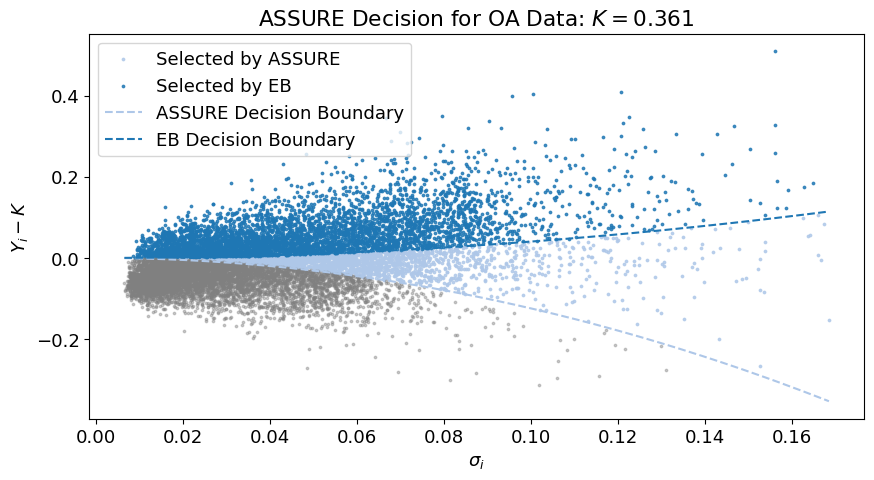

In [97]:
from matplotlib.cm import get_cmap
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots(1,1, figsize = (10,5))

opt_mask = (estimates > cost + opt_beta*sigmas**2)
eb_mask = (estimates > cost + eb_beta*sigmas**2)



tab20 = get_cmap('tab20').colors  # list of 20 RGBA tuples
eb_col = tab20[0]
opt_col = tab20[1]


ax.scatter(standard_errors[opt_mask & ~eb_mask],
           estimates[opt_mask & ~eb_mask] - cost,
              s = 3, color = opt_col, alpha = 0.8, label = "Selected by ASSURE", rasterized=True)


ax.scatter(standard_errors[eb_mask],
           estimates[eb_mask] - cost,
              s = 3, color = eb_col, alpha = 0.8, label = "Selected by EB", rasterized=True)

ax.scatter(standard_errors[~opt_mask], estimates[~opt_mask] - cost, s = 3, color = "grey", alpha = 0.4, rasterized=True)
ax.set_ylabel("$Y_i - K$")
ax.set_xlabel("$\sigma_i$")
ax.set_title(f"ASSURE Decision for OA Data: $K = {cost}$")

sigmas_sorted = np.sort(sigmas)
ax.plot(sigmas_sorted, opt_beta*sigmas_sorted**2, color = opt_col, linestyle = "dashed", label = "ASSURE Decision Boundary")
ax.plot(sigmas_sorted, eb_beta*sigmas_sorted**2, color = eb_col, linestyle = "dashed", label = "EB Decision Boundary")

plt.legend()
plt.savefig(f"../results/oa_analysis/oa_decision_viz_cost{cost}.pdf", bbox_inches = "tight")